In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("customer_segmentation_1000.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending,Spending_Score,Visit_Per_Month
0,1,Male,58,28278,14012,52,8
1,2,Male,32,78265,76482,41,3
2,3,Female,55,54165,11140,21,7
3,4,Male,32,66781,51925,47,21
4,5,Female,62,53893,43618,33,9


In [4]:
NAME    HEIGHT      W
A       163         40     
B       175        68
C       160          58
D       156         63
E       170         86   

SyntaxError: invalid syntax (3025393572.py, line 1)

In [ ]:
COSINE DISTANCE

STUDENT A
PYTHON
JAVA
SQL


STUDENT B

PYTHON
JAVA
SQL
simalarity of A AND B =1

STUDENT C
COOKING
SINGING
PLAYING

cosine=0

COSINE(0)=A.B/|A||B|

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

A=[[5,4,0]]
B=[[5,0,1]]
print(cosine_similarity(A,B))

[[0.76570486]]


In [8]:
A=[[5,4,1]]
B=[[1,5,5]]
print(cosine_similarity(A,B))

[[0.64820372]]


In [9]:
df

,CustomerID,Gender,Age,Annual_Income,Spending,Spending_Score,Visit_Per_Month
0,1,Male,58,28278,14012,52,8
1,2,Male,32,78265,76482,41,3
2,3,Female,55,54165,11140,21,7
3,4,Male,32,66781,51925,47,21
4,5,Female,62,53893,43618,33,9
...,...,...,...,...,...,...,...
995,996,Female,38,44323,22634,71,6
996,997,Male,65,90404,31170,52,8
997,998,Male,65,59787,20021,18,7
998,999,Female,33,40223,11991,84,4


In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       1000 non-null   int64 
 1   Gender           1000 non-null   object
 2   Age              1000 non-null   int64 
 3   Annual_Income    1000 non-null   int64 
 4   Spending         1000 non-null   int64 
 5   Spending_Score   1000 non-null   int64 
 6   Visit_Per_Month  1000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 54.8+ KB


In [12]:
df.describe()

,CustomerID,Age,Annual_Income,Spending,Spending_Score,Visit_Per_Month
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,44.448000,66191.188000,37012.390000,53.361000,14.904000
std,288.819436,15.366113,29095.628608,24412.342932,23.221238,8.522407
min,1.000000,18.000000,15022.000000,5102.000000,5.000000,1.000000
25%,250.750000,31.000000,41876.000000,17616.500000,36.000000,8.000000
50%,500.500000,45.000000,65450.000000,31600.500000,54.000000,15.000000
75%,750.250000,58.000000,84925.000000,51404.750000,72.000000,22.000000
max,1000.000000,70.000000,139928.000000,137989.000000,100.000000,30.000000


In [13]:
df.isnull().sum()

CustomerID         0
Gender             0
Age                0
Annual_Income      0
Spending           0
Spending_Score     0
Visit_Per_Month    0
dtype: int64

In [14]:
df

,CustomerID,Gender,Age,Annual_Income,Spending,Spending_Score,Visit_Per_Month
0,1,Male,58,28278,14012,52,8
1,2,Male,32,78265,76482,41,3
2,3,Female,55,54165,11140,21,7
3,4,Male,32,66781,51925,47,21
4,5,Female,62,53893,43618,33,9
...,...,...,...,...,...,...,...
995,996,Female,38,44323,22634,71,6
996,997,Male,65,90404,31170,52,8
997,998,Male,65,59787,20021,18,7
998,999,Female,33,40223,11991,84,4


In [15]:
X=df[['Annual_Income','Spending_Score']]

In [16]:
X

,Annual_Income,Spending_Score
0,28278,52
1,78265,41
2,54165,21
3,66781,47
4,53893,33
...,...,...
995,44323,71
996,90404,52
997,59787,18
998,40223,84


In [17]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(X)

In [18]:
X

,Annual_Income,Spending_Score
0,28278,52
1,78265,41
2,54165,21
3,66781,47
4,53893,33
...,...,...
995,44323,71
996,90404,52
997,59787,18
998,40223,84


In [19]:
abc=[]
for k in range(1,11):
    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(x_scaled)
    abc.append(model.inertia_)

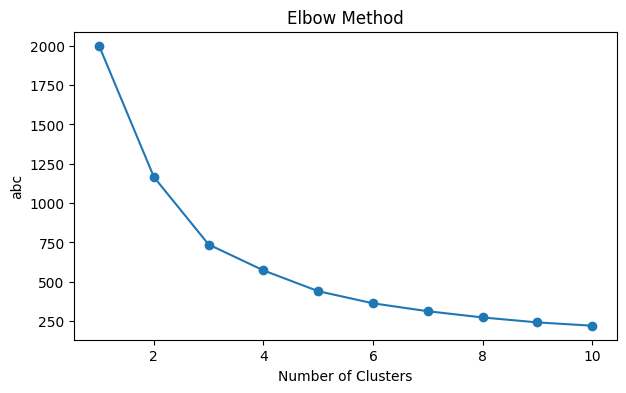

In [20]:
plt.figure(figsize=(7,4))
plt.plot(range(1,11),abc,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("abc")
plt.title("Elbow Method")
plt.show()

In [22]:
kmeans=KMeans(n_clusters=5,random_state=42,n_init=10)
df['Cluter']=kmeans.fit_predict(x_scaled)
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending,Spending_Score,Visit_Per_Month,Cluter
0,1,Male,58,28278,14012,52,8,4
1,2,Male,32,78265,76482,41,3,0
2,3,Female,55,54165,11140,21,7,4
3,4,Male,32,66781,51925,47,21,4
4,5,Female,62,53893,43618,33,9,4


In [23]:
df

,CustomerID,Gender,Age,Annual_Income,Spending,Spending_Score,Visit_Per_Month,Cluter
0,1,Male,58,28278,14012,52,8,4
1,2,Male,32,78265,76482,41,3,0
2,3,Female,55,54165,11140,21,7,4
3,4,Male,32,66781,51925,47,21,4
4,5,Female,62,53893,43618,33,9,4
...,...,...,...,...,...,...,...,...
995,996,Female,38,44323,22634,71,6,1
996,997,Male,65,90404,31170,52,8,3
997,998,Male,65,59787,20021,18,7,0
998,999,Female,33,40223,11991,84,4,1


In [24]:
df['Cluter'].unique()

array([4, 0, 1, 3, 2], dtype=int32)

In [25]:
plt.figure(figsize=(7,4))

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

In [26]:
for c in sorted(df['Cluter'].unique()):
    print(c)

0
1
2
3
4


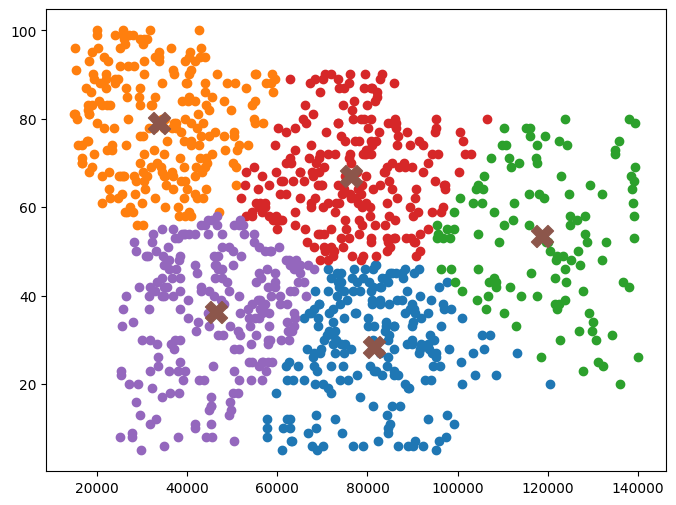

In [ ]:
plt.figure(figsize=(8,6))

for c in sorted(df["Cluter"].unique()):
    temp = df[df["Cluter"] == c]
    plt.scatter(
        temp["Annual_Income"],
        temp["Spending_Score"],
        label=f"Cluster {c}"
    )

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:,0],
    centers[:,1],
    marker="X",
    legend=c
    s=250,
    label="Centroids"
)

In [34]:
print(predict_customer_cluster(75000,75))

3


c:\Users\Vishnu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


<Axes: xlabel='Annual_Income', ylabel='Spending_Score'>

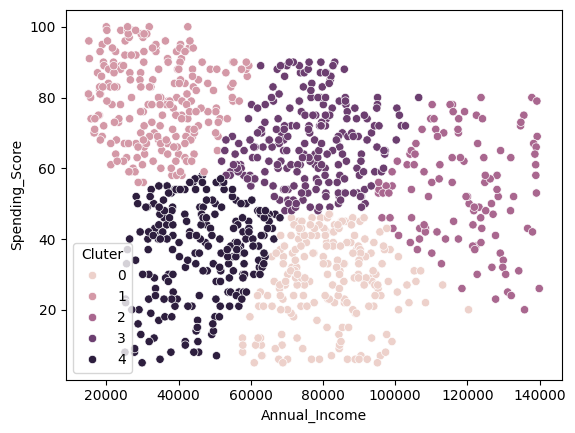

In [33]:
import seaborn as sns
sns.scatterplot(x=df['Annual_Income'],
                y=df['Spending_Score'],
                hue=df['Cluter'])

In [28]:
df

,CustomerID,Gender,Age,Annual_Income,Spending,Spending_Score,Visit_Per_Month,Cluter
0,1,Male,58,28278,14012,52,8,4
1,2,Male,32,78265,76482,41,3,0
2,3,Female,55,54165,11140,21,7,4
3,4,Male,32,66781,51925,47,21,4
4,5,Female,62,53893,43618,33,9,4
...,...,...,...,...,...,...,...,...
995,996,Female,38,44323,22634,71,6,1
996,997,Male,65,90404,31170,52,8,3
997,998,Male,65,59787,20021,18,7,0
998,999,Female,33,40223,11991,84,4,1


In [31]:
def predict_customer_cluster(income,spending_score):
    sample=[[income,spending_score]]
    scaled=scaler.transform(sample)
    cluster=kmeans.predict(scaled)[0]
    return cluster
    


In [32]:
print(predict_customer_cluster(90000,80))


3


c:\Users\Vishnu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [33]:
print(predict_customer_cluster(10000,80))

1


c:\Users\Vishnu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [35]:
df.to_csv("Clusted_data.csv")
print("data exported succesfully")

data exported succesfully
